In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

# Load processed data
print("Loading processed data...")
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Class imbalance ratio: 1:{int(y_train.value_counts()[0]/y_train.value_counts()[1])}")
print("\nData loaded. Ready for training.")

Loading processed data...
X_train: (472432, 363)
X_test:  (118108, 363)
Class imbalance ratio: 1:27

Data loaded. Ready for training.


In [2]:
# Train XGBoost model
# scale_pos_weight=27 handles class imbalance (ratio 1:27)
print("Training XGBoost model...")
print("This may take 3-5 minutes...\n")

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=27,  # handles class imbalance
    random_state=42,
    eval_metric='aucpr',  # area under precision-recall curve, better for imbalanced data
    early_stopping_rounds=20,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50  # print every 50 rounds
)

print("\nTraining complete.")
print(f"Best iteration: {model.best_iteration}")

Training XGBoost model...
This may take 3-5 minutes...

[0]	validation_0-aucpr:0.35732
[50]	validation_0-aucpr:0.50580
[100]	validation_0-aucpr:0.56373
[150]	validation_0-aucpr:0.59433
[200]	validation_0-aucpr:0.61834
[250]	validation_0-aucpr:0.63631
[299]	validation_0-aucpr:0.65187

Training complete.
Best iteration: 299


In [3]:
# Model Evaluation
print("Evaluating model...")

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Core metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

print(f"ROC-AUC Score:        {roc_auc:.4f}")
print(f"Average Precision:    {avg_precision:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

Evaluating model...
ROC-AUC Score:        0.9356
Average Precision:    0.6519

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.91      0.95    113975
       Fraud       0.25      0.81      0.38      4133

    accuracy                           0.91    118108
   macro avg       0.62      0.86      0.67    118108
weighted avg       0.97      0.91      0.93    118108



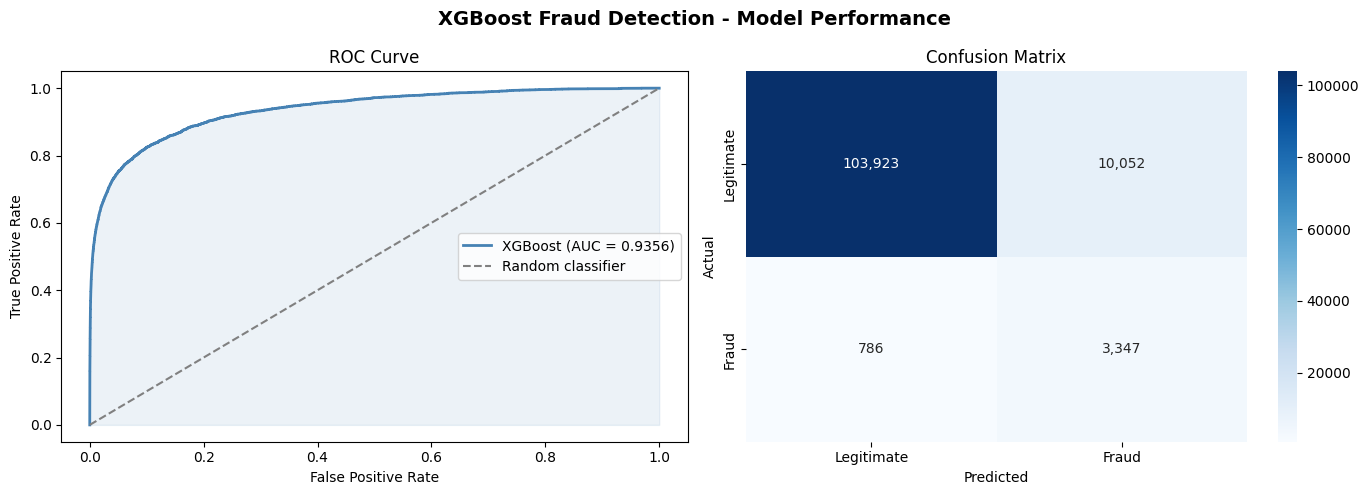

True Negatives  (Correct Legitimate): 103,923
False Positives (False Alarms):        10,052
False Negatives (Missed Fraud):        786
True Positives  (Caught Fraud):        3,347

False Positive Rate: 8.8%
False Negative Rate: 19.0%


In [4]:
# Visualization - ROC Curve + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, 
             label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('XGBoost Fraud Detection - Model Performance', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correct Legitimate): {tn:,}")
print(f"False Positives (False Alarms):        {fp:,}")
print(f"False Negatives (Missed Fraud):        {fn:,}")
print(f"True Positives  (Caught Fraud):        {tp:,}")
print(f"\nFalse Positive Rate: {fp/(fp+tn)*100:.1f}%")
print(f"False Negative Rate: {fn/(fn+tp)*100:.1f}%")

Default threshold (0.50):
  Precision: 0.25 | Recall: 0.81 | F1: 0.38

Optimal threshold (0.83):
  Precision: 0.69 | Recall: 0.56 | F1: 0.62


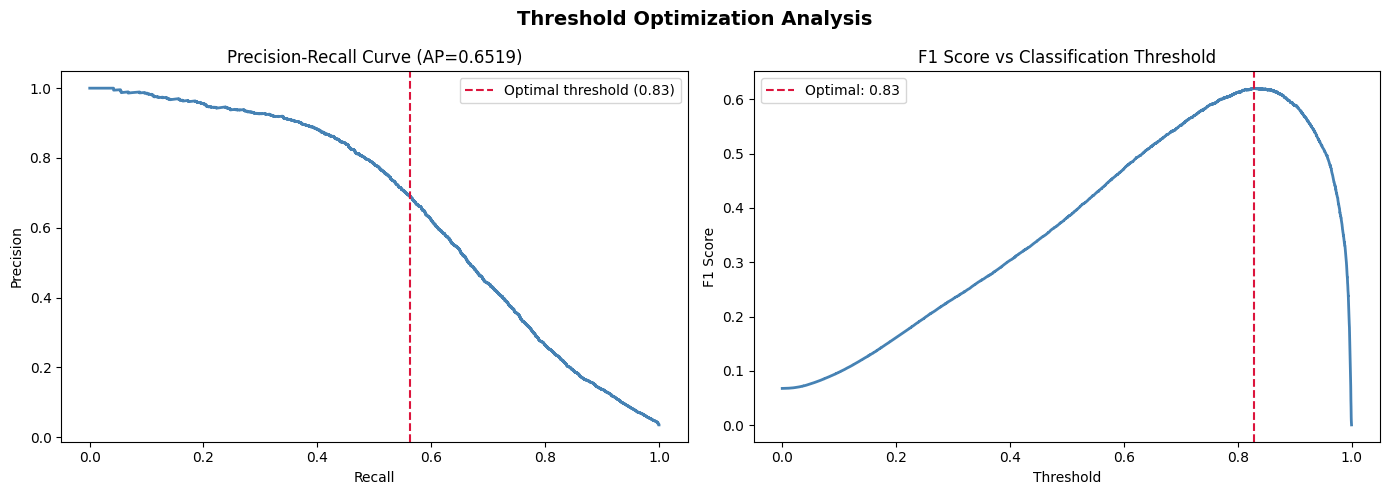

In [5]:
# Threshold Optimization
# Goal: find optimal threshold balancing precision and recall
# In AML context, false positives = wasted investigator resources
# false negatives = missed fraud = financial loss

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1 score for each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Default threshold (0.50):")
print(f"  Precision: 0.25 | Recall: 0.81 | F1: 0.38")

print(f"\nOptimal threshold ({optimal_threshold:.2f}):")
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
from sklearn.metrics import precision_score, recall_score, f1_score
print(f"  Precision: {precision_score(y_test, y_pred_optimal):.2f} | "
      f"Recall: {recall_score(y_test, y_pred_optimal):.2f} | "
      f"F1: {f1_score(y_test, y_pred_optimal):.2f}")

# Plot Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall Curve
axes[0].plot(recalls[:-1], precisions[:-1], color='steelblue', lw=2)
axes[0].axvline(x=recalls[optimal_idx], color='crimson', 
                linestyle='--', label=f'Optimal threshold ({optimal_threshold:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall Curve (AP={avg_precision:.4f})')
axes[0].legend()

# Plot 2: F1 Score vs Threshold
axes[1].plot(thresholds, f1_scores, color='steelblue', lw=2)
axes[1].axvline(x=optimal_threshold, color='crimson', 
                linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Classification Threshold')
axes[1].legend()

plt.suptitle('Threshold Optimization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

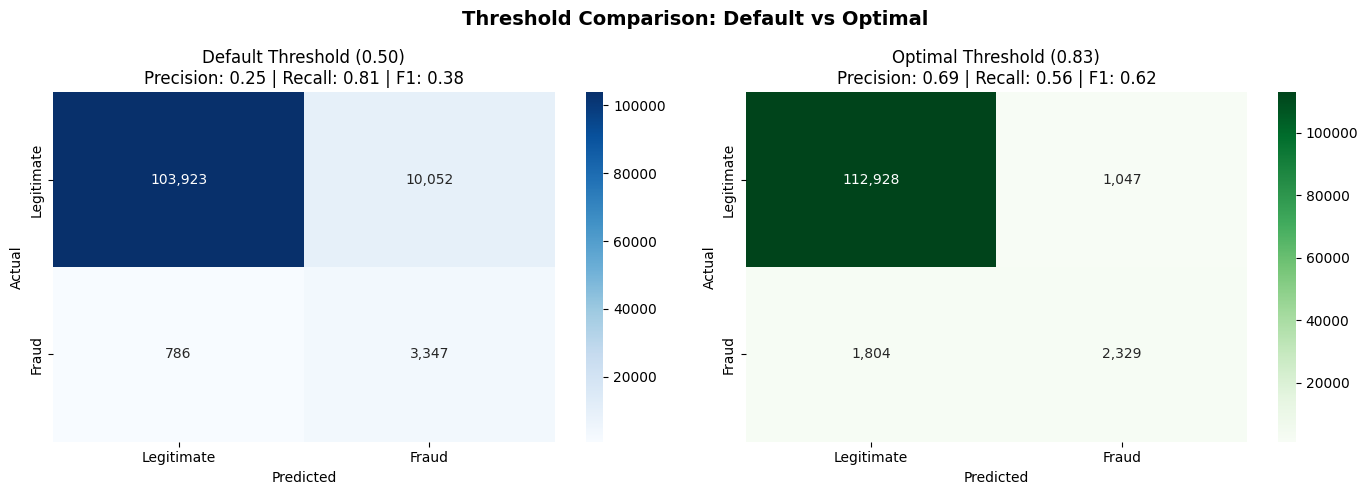

=== BUSINESS IMPACT SUMMARY ===

False Alarms (False Positives):
  Default  (0.50): 10,052 unnecessary investigations
  Optimal  (0.83): 1,047 unnecessary investigations
  Reduction: 9,005 fewer false alarms (89.6% improvement)

Missed Fraud (False Negatives):
  Default  (0.50): 786 missed fraud cases
  Optimal  (0.83): 1,804 missed fraud cases
  Trade-off: 1,018 additional missed cases


In [6]:
# Compare confusion matrices: default vs optimal threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold (0.50)
cm_default = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_default, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('Default Threshold (0.50)\nPrecision: 0.25 | Recall: 0.81 | F1: 0.38')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Optimal threshold (0.83)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt=',', cmap='Greens', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[1].set_title(f'Optimal Threshold ({optimal_threshold:.2f})\nPrecision: 0.69 | Recall: 0.56 | F1: 0.62')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Threshold Comparison: Default vs Optimal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Business impact summary
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()
tn_o, fp_o, fn_o, tp_o = cm_optimal.ravel()

print("=== BUSINESS IMPACT SUMMARY ===")
print(f"\nFalse Alarms (False Positives):")
print(f"  Default  (0.50): {fp_d:,} unnecessary investigations")
print(f"  Optimal  (0.83): {fp_o:,} unnecessary investigations")
print(f"  Reduction: {fp_d - fp_o:,} fewer false alarms ({(1-fp_o/fp_d)*100:.1f}% improvement)")

print(f"\nMissed Fraud (False Negatives):")
print(f"  Default  (0.50): {fn_d:,} missed fraud cases")
print(f"  Optimal  (0.83): {fn_o:,} missed fraud cases")
print(f"  Trade-off: {fn_o - fn_d:,} additional missed cases")